# DICOM CT Scan Visualisation
This notebook loads CQ500 DICOM files and displays CT slices using standard brain windowing presets.

In [1]:
import sys
sys.path.insert(0, '..')  # make src/ importable when running from notebooks/

from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import pydicom

from src.data.preprocessing import apply_window, clip_hu, hu_to_3channel, CT_WINDOWS


In [2]:
RAW_DIR = Path('../data/raw')

# Collect all DICOM files across all studies
all_dcm = sorted(RAW_DIR.rglob('*.dcm'))
print(f'Total DICOM files found: {len(all_dcm)}')

# Show available studies
studies = sorted({p.parts[-4] for p in all_dcm})
for s in studies:
    count = sum(1 for p in all_dcm if p.parts[-4] == s)
    print(f'  {s}  →  {count} slices')

Total DICOM files found: 392
  CQ500CT1 CQ500CT1  →  36 slices
  CQ500CT24 CQ500CT24  →  32 slices
  CQ500CT25 CQ500CT25  →  324 slices


## 1. Inspect raw DICOM metadata
Before viewing the image, explore what metadata a DICOM file carries.

In [10]:
sample_dcm_path = all_dcm[0]
dcm = pydicom.dcmread(str(sample_dcm_path))

print(f'File         : {sample_dcm_path.name}')
print(f'Patient ID   : {getattr(dcm, "PatientID", "N/A")}')
print(f'Study Date   : {getattr(dcm, "StudyDate", "N/A")}')
print(f'Modality     : {getattr(dcm, "Modality", "N/A")}')
print(f'Rows x Cols  : {dcm.Rows} x {dcm.Columns}')
print(f'Pixel Spacing: {getattr(dcm, "PixelSpacing", "N/A")}')
print(f'Slice Location: {getattr(dcm, "SliceLocation", "N/A")}')
print(f'Rescale Slope: {getattr(dcm, "RescaleSlope", 1)}')
print(f'Rescale Intercept: {getattr(dcm, "RescaleIntercept", 0)}')

File         : CT000000.dcm
Patient ID   : CQ500-CT-1
Study Date   : 
Modality     : CT
Rows x Cols  : 512 x 512
Pixel Spacing: [0.564453, 0.564453]
Slice Location: 34.780
Rescale Slope: 1
Rescale Intercept: -1024


## 2. Convert raw pixel data to Hounsfield Units (HU)
DICOM pixel values must be converted to HU using the rescale slope and intercept stored in the file header.

In [4]:
slope = float(getattr(dcm, 'RescaleSlope', 1))
intercept = float(getattr(dcm, 'RescaleIntercept', 0))

raw_pixels = dcm.pixel_array.astype(np.float32)
hu = raw_pixels * slope + intercept
hu = clip_hu(hu)  # clip to [-1000, 3000]

print(f'HU range after clipping: min={hu.min():.0f}  max={hu.max():.0f}')
print(f'Image shape: {hu.shape}')

HU range after clipping: min=-1000  max=1509
Image shape: (512, 512)


## 3. View a single slice — three CT windows side by side
Each window highlights different tissue types:
- **Brain window** (C=40, W=80) → differentiates grey/white matter and blood
- **Subdural window** (C=75, W=215) → optimal for subdural haematomas
- **Bone window** (C=600, W=2800) → skull and calcification

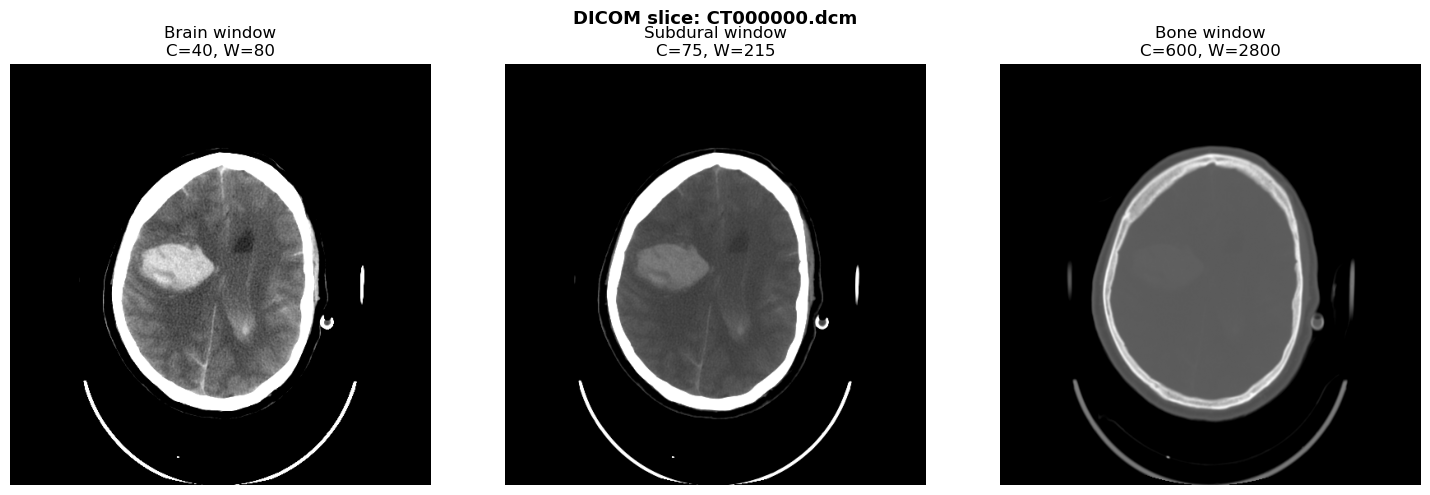

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, (name, (center, width)) in zip(axes, CT_WINDOWS.items()):
    windowed = apply_window(hu, center, width)
    ax.imshow(windowed, cmap='gray')
    ax.set_title(f'{name.capitalize()} window\nC={center}, W={width}', fontsize=12)
    ax.axis('off')

plt.suptitle(f'DICOM slice: {sample_dcm_path.name}', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 4. View the 3-channel input fed to the model
The three windows are stacked as R, G, B channels — this is exactly what the EfficientNet/ResNet model receives.

3-channel image shape: (512, 512, 3)


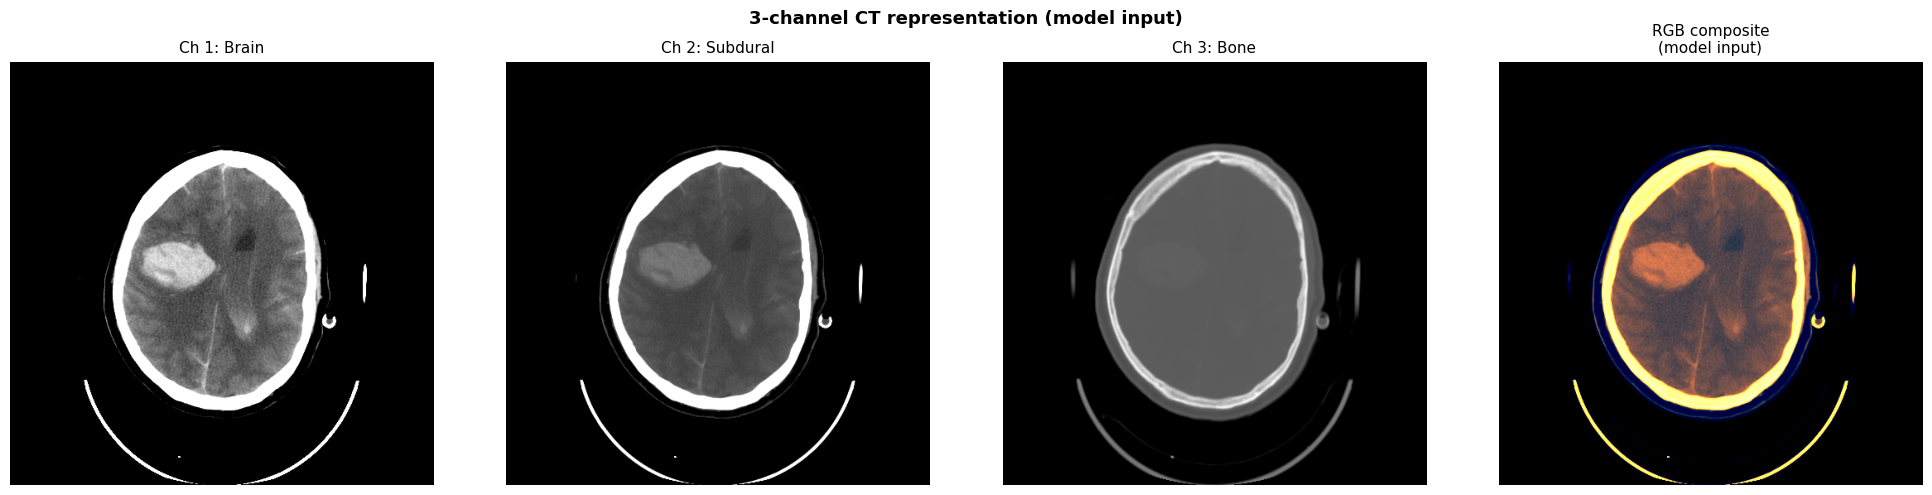

In [6]:
three_ch = hu_to_3channel(hu)  # shape: (H, W, 3), values in [0, 1]
print(f'3-channel image shape: {three_ch.shape}')

fig, axes = plt.subplots(1, 4, figsize=(20, 5))

# Individual channels
channel_names = list(CT_WINDOWS.keys())
for i, (ax, name) in enumerate(zip(axes[:3], channel_names)):
    ax.imshow(three_ch[:, :, i], cmap='gray')
    ax.set_title(f'Ch {i+1}: {name.capitalize()}', fontsize=11)
    ax.axis('off')

# RGB composite
axes[3].imshow(three_ch)
axes[3].set_title('RGB composite\n(model input)', fontsize=11)
axes[3].axis('off')

plt.suptitle('3-channel CT representation (model input)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 5. Browse slices across a full study
View multiple slices from one study sorted by anatomical position.

Study series : ../data/raw/CQ500CT25 CQ500CT25/Unknown Study/CT Thin Plain
Total slices : 288


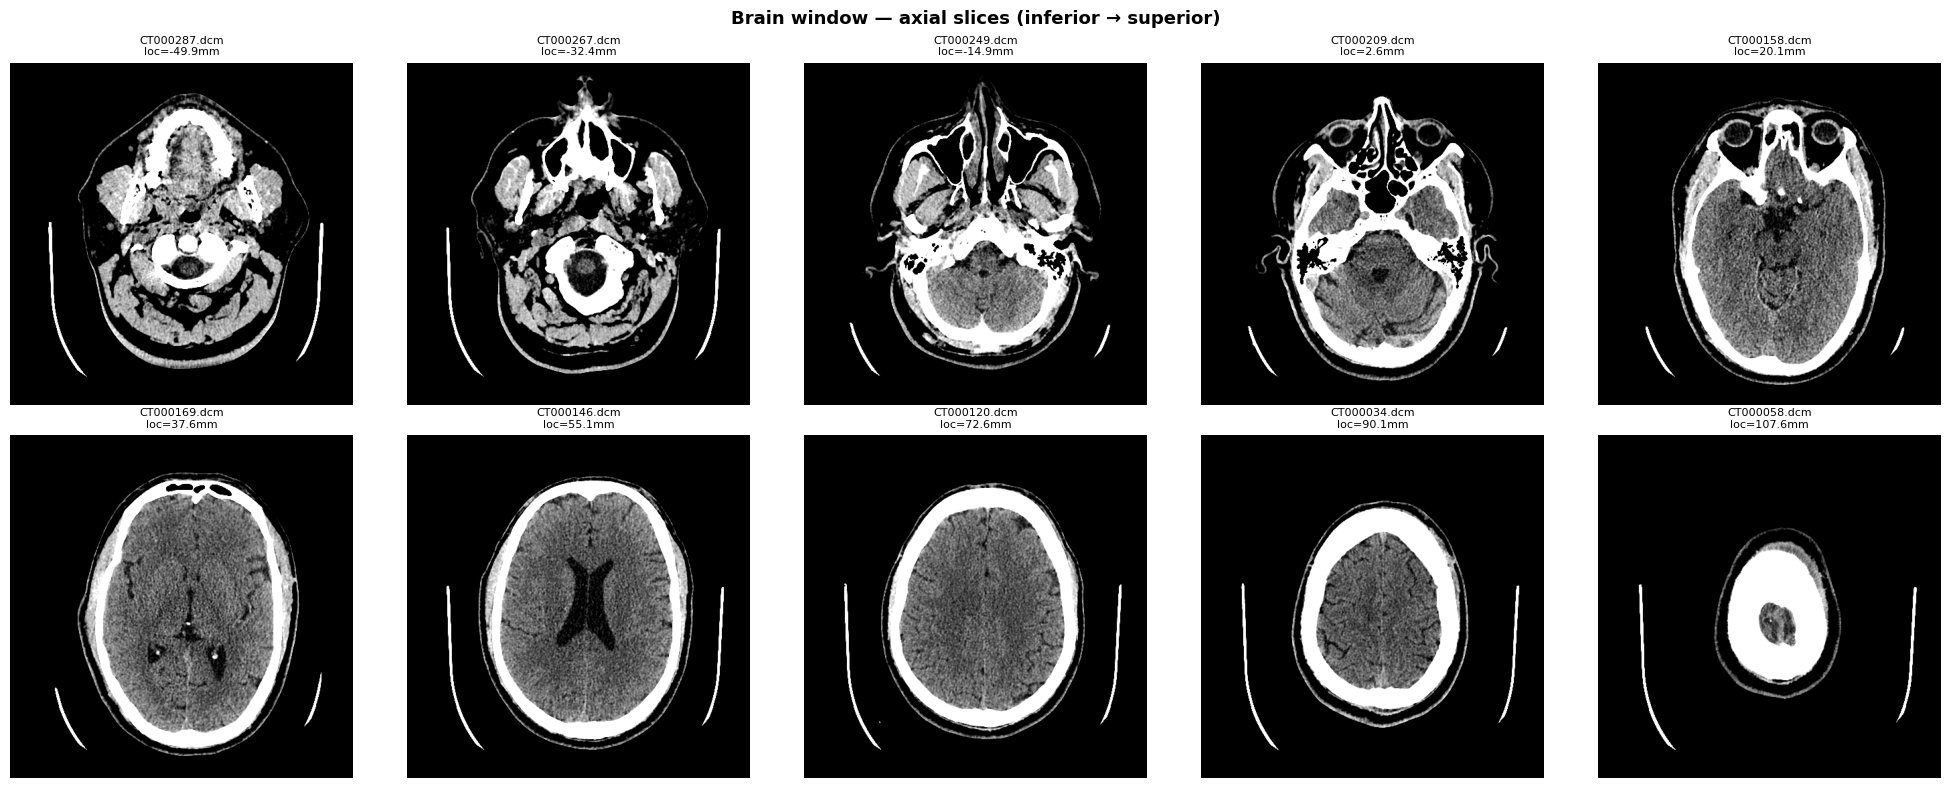

In [8]:
# Pick the first available study
study_dir = sorted(RAW_DIR.glob('*/Unknown Study/*/'))[-1]  # first series
study_dcms = sorted(study_dir.glob('*.dcm'))
print(f'Study series : {study_dir}')
print(f'Total slices : {len(study_dcms)}')

# Sort by slice location
def slice_location(p):
    d = pydicom.dcmread(str(p), stop_before_pixels=True)
    return float(getattr(d, 'SliceLocation', 0))

study_dcms_sorted = sorted(study_dcms, key=slice_location)

# Display every Nth slice
N = max(1, len(study_dcms_sorted) // 10)
selected = study_dcms_sorted[::N][:10]

fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.flatten()

for ax, dcm_path in zip(axes, selected):
    d = pydicom.dcmread(str(dcm_path))
    hu_slice = d.pixel_array.astype(np.float32) * float(getattr(d, 'RescaleSlope', 1)) + float(getattr(d, 'RescaleIntercept', 0))
    brain_win = apply_window(clip_hu(hu_slice), center=40, width=80)
    ax.imshow(brain_win, cmap='gray')
    loc = float(getattr(d, 'SliceLocation', 0))
    ax.set_title(f'{dcm_path.name}\nloc={loc:.1f}mm', fontsize=8)
    ax.axis('off')

# Hide unused axes
for ax in axes[len(selected):]:
    ax.set_visible(False)

plt.suptitle('Brain window — axial slices (inferior → superior)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 6. Pixel intensity (HU) histogram
A useful sanity check — shows tissue composition of the slice.

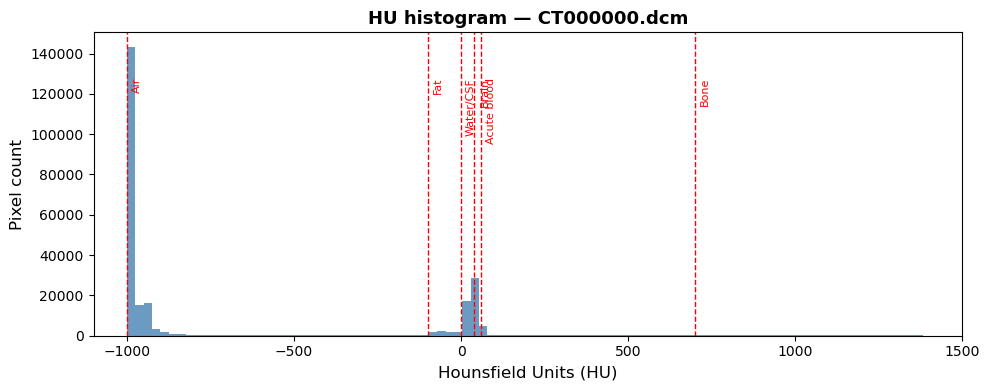

In [9]:
fig, ax = plt.subplots(figsize=(10, 4))

ax.hist(hu.flatten(), bins=100, color='steelblue', edgecolor='none', alpha=0.8)

# Annotate tissue reference HU values
tissue_hu = {
    'Air': -1000,
    'Fat': -100,
    'Water/CSF': 0,
    'Brain': 40,
    'Acute blood': 60,
    'Bone': 700,
}
for label, val in tissue_hu.items():
    ax.axvline(val, color='red', linestyle='--', linewidth=1)
    ax.text(val + 15, ax.get_ylim()[1] * 0.85, label, fontsize=8, color='red', rotation=90, va='top')

ax.set_xlabel('Hounsfield Units (HU)', fontsize=12)
ax.set_ylabel('Pixel count', fontsize=12)
ax.set_title(f'HU histogram — {sample_dcm_path.name}', fontsize=13, fontweight='bold')
ax.set_xlim(-1100, 1500)
plt.tight_layout()
plt.show()